# EDA датасета 3D-мешей

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

train = pd.read_csv('train(1).csv')
train_dir = Path('train (2)') / 'train'


In [6]:
print('Размер train:', train.shape)
train.head()

Размер train: (8964, 12)


,item_id,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
0,0001be62-bf9c-4c15-8a09-dce209be9715,0,1,0,0,0,0,0,0,0,0,0
1,000ad3b9-75cf-4b8f-9786-de63f9a8ffa8,0,0,0,0,0,0,0,0,0,1,0
2,0012e069-5caf-44fd-85e4-9a38f6eefd2e,0,0,0,0,0,0,0,0,0,1,0
3,0024dc8f-a2d7-4556-94dc-6b4b0f46ca0d,1,0,0,1,0,0,0,0,0,0,0
4,002b097b-4237-4610-952c-6095d48fb7a0,0,0,0,0,0,0,0,0,0,1,0


## Проверка пропусков

In [7]:
print('Пропуски в train:')
display(train.isna().sum())


Пропуски в train:


item_id         0
abstract        0
artifacts       0
intersection    0
lowpoly         0
noisy           0
open            0
partial         0
scale           0
set             0
simple          0
quality         0
dtype: int64

## Проверка дубликатов

In [8]:
print('Полностью одинаковых строк в train:', train.duplicated().sum())
print('Повторяющихся item_id в train:', train['item_id'].duplicated().sum())


Полностью одинаковых строк в train: 0
Повторяющихся item_id в train: 0


## Распределение качества

In [9]:
quality_counts = train['quality'].value_counts().sort_index()
quality_percent = train['quality'].value_counts(normalize=True).sort_index() * 100

quality_distribution = pd.DataFrame({
    'Количество': quality_counts,
    'Доля, %': quality_percent.round(2)
})

quality_distribution.index = ['Плохие', 'Хорошие']
quality_distribution

,Количество,"Доля, %"
Плохие,7592,84.69
Хорошие,1372,15.31


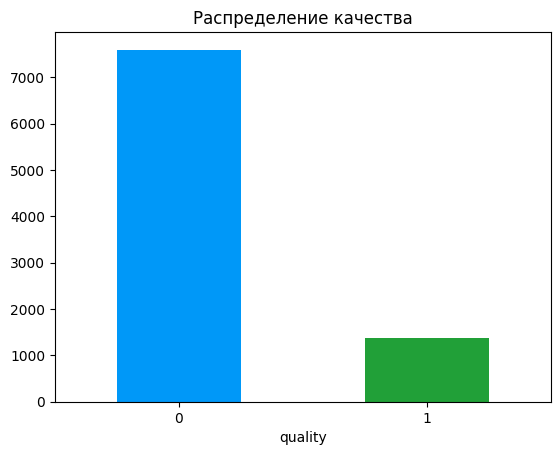

In [10]:
quality_counts.plot(
    kind='bar',
    color=['#0098F8', '#21A038'],
    rot=0,
    title='Распределение качества'
);

## Распределение дефектов

In [11]:
defect_columns = [
    'abstract', 'artifacts', 'intersection', 'lowpoly', 'noisy',
    'open', 'partial', 'scale', 'set', 'simple'
]

defect_distribution = pd.DataFrame({
    'Количество': train[defect_columns].sum(),
    'Доля, %': (train[defect_columns].mean() * 100).round(2)
}).sort_values('Количество', ascending=False)

defect_distribution

,Количество,"Доля, %"
noisy,2549,28.44
simple,1929,21.52
abstract,1194,13.32
lowpoly,1107,12.35
set,936,10.44
open,544,6.07
artifacts,435,4.85
partial,376,4.19
intersection,107,1.19
scale,107,1.19


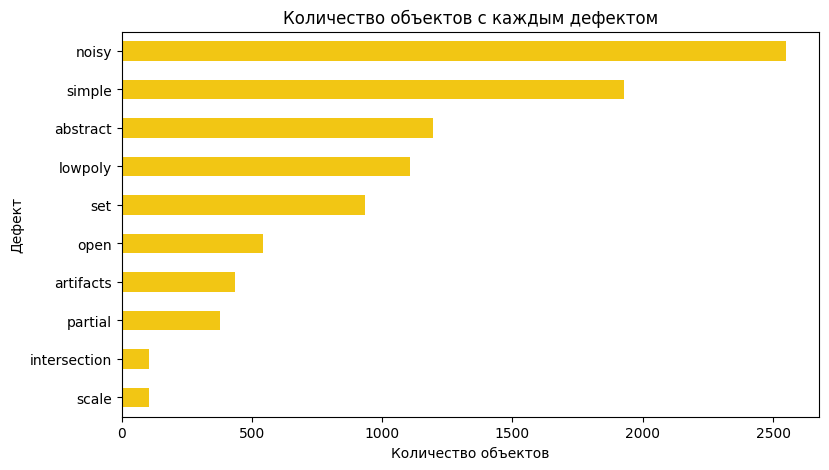

In [12]:
ax = defect_distribution['Количество'].sort_values().plot(
    kind='barh',
    figsize=(9, 5),
    color='#F2C614',
    title='Количество объектов с каждым дефектом'
)

ax.set_xlabel('Количество объектов')
ax.set_ylabel('Дефект');

## Количество дефектов у объекта

In [13]:
train['defect_count'] = train[defect_columns].sum(axis=1)

defect_count_distribution = train['defect_count'].value_counts().sort_index()
defect_count_distribution.to_frame('Количество объектов')

,Количество объектов
defect_count,
0,1372
1,6372
2,878
3,251
4,59
5,25
6,7


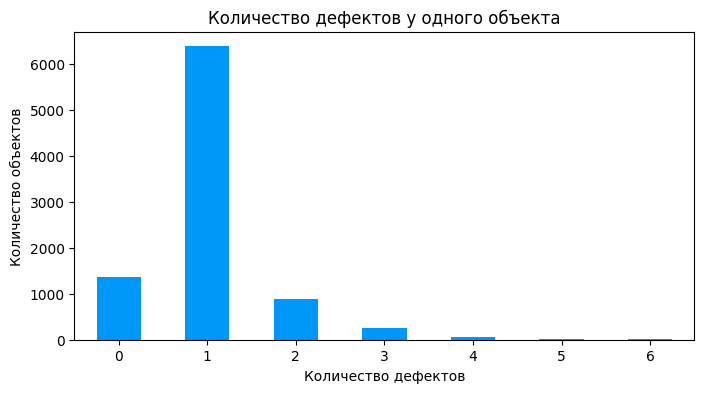

In [14]:
ax = defect_count_distribution.plot(
    kind='bar',
    figsize=(8, 4),
    color='#0098F8',
    rot=0,
    title='Количество дефектов у одного объекта'
)

ax.set_xlabel('Количество дефектов')
ax.set_ylabel('Количество объектов');

## Корреляция дефектов

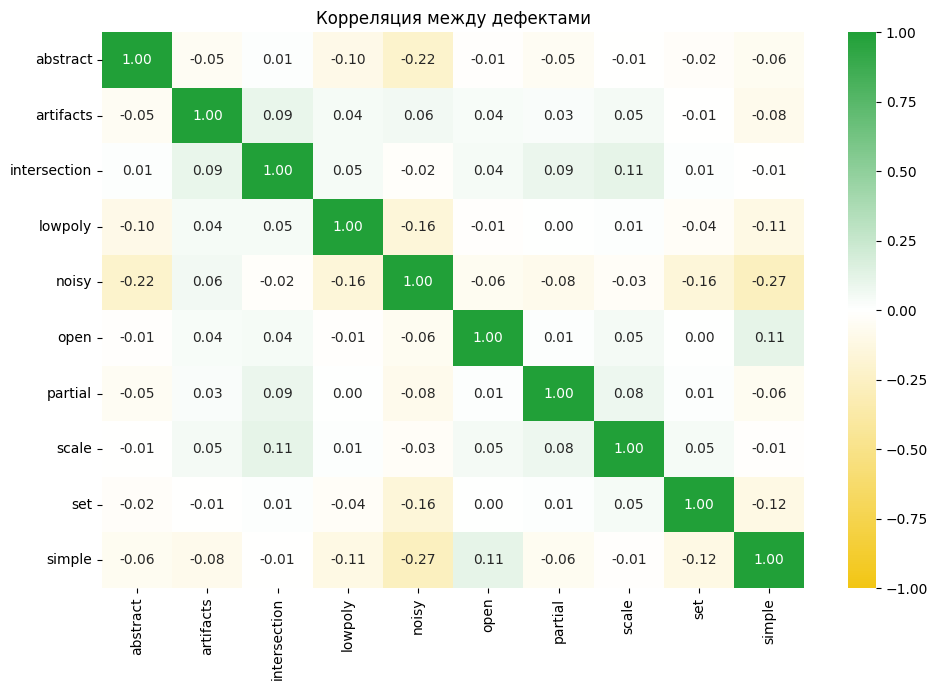

In [15]:
defect_correlation = train[defect_columns].corr()

correlation_cmap = LinearSegmentedColormap.from_list(
    'correlation_palette', ['#F2C614', '#FFFFFF', '#21A038']
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    defect_correlation,
    annot=True,
    fmt='.2f',
    cmap=correlation_cmap,
    vmin=-1,
    vmax=1
)
plt.title('Корреляция между дефектами')
plt.tight_layout()
plt.show()

## Топ-10 коррелирующих пар дефектов

In [16]:
pairs = []

for i, first_defect in enumerate(defect_columns):
    for second_defect in defect_columns[i + 1:]:
        correlation = defect_correlation.loc[first_defect, second_defect]
        pairs.append([first_defect, second_defect, correlation])

top_correlations = pd.DataFrame(
    pairs,
    columns=['Дефект 1', 'Дефект 2', 'Корреляция']
)

top_correlations['По модулю'] = top_correlations['Корреляция'].abs()

top_correlations = (
    top_correlations
    .sort_values('По модулю', ascending=False)
    .head(10)
    .drop(columns='По модулю')
    .reset_index(drop=True)
)

top_correlations.index += 1
top_correlations.round(3)

,Дефект 1,Дефект 2,Корреляция
1,noisy,simple,-0.271
2,abstract,noisy,-0.217
3,noisy,set,-0.163
4,lowpoly,noisy,-0.161
5,set,simple,-0.117
6,lowpoly,simple,-0.113
7,intersection,scale,0.111
8,open,simple,0.110
9,abstract,lowpoly,-0.097
10,artifacts,intersection,0.095


## Проверка файлов

In [18]:
file_counts = pd.DataFrame({
    'Таблица': [len(train)],
    'PNG': [len(list(train_dir.glob('*.png')))],
    'NPZ': [len(list(train_dir.glob('*.npz')))]
}, index=['Train'])

file_counts

,Таблица,PNG,NPZ
Train,8964,8964,8964


## Связь качества и дефектов

In [19]:
quality_from_defects = (train[defect_columns].sum(axis=1) == 0).astype(int)

print(
    'Объектов, у которых quality не соответствует наличию дефектов:',
    (train['quality'] != quality_from_defects).sum()
)

Объектов, у которых quality не соответствует наличию дефектов: 0


## Примеры объектов

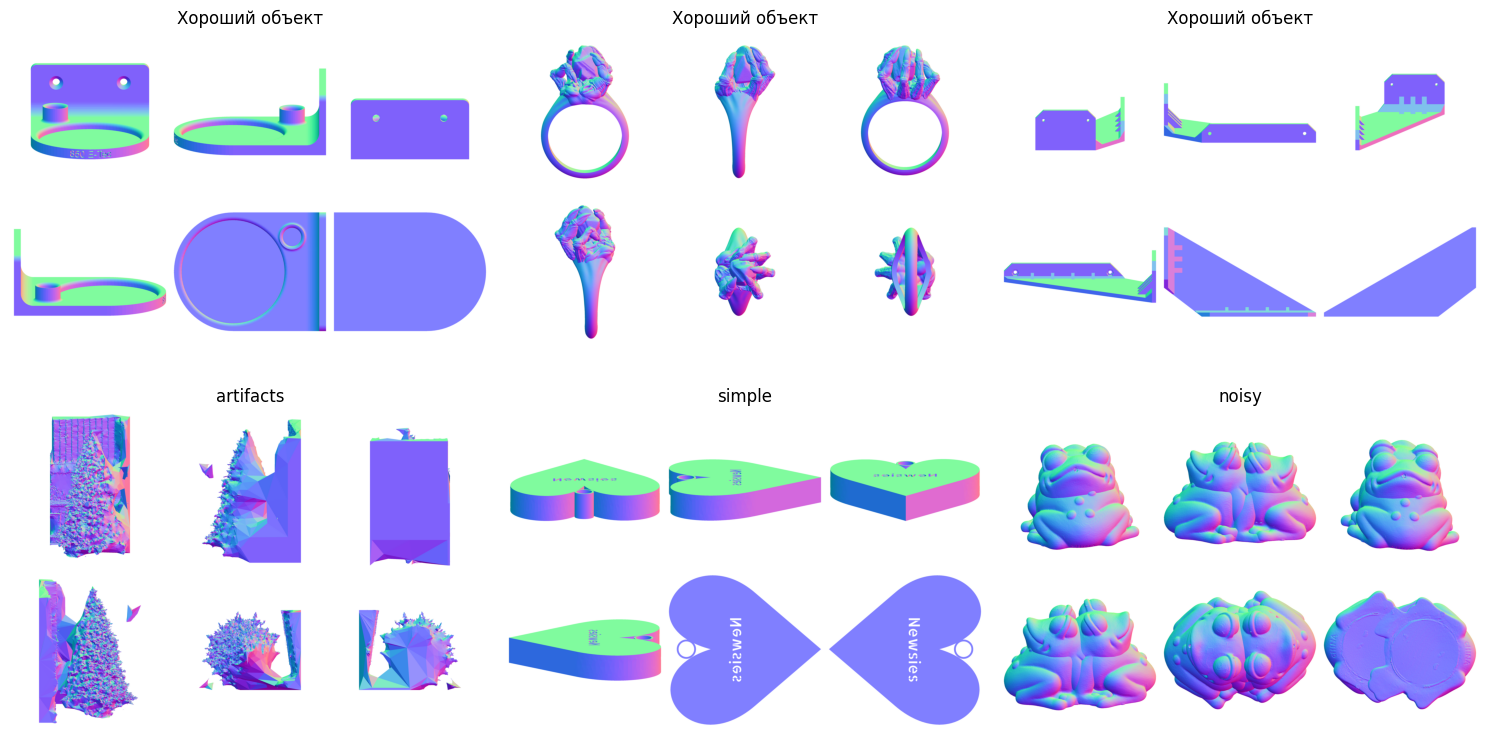

In [20]:
good_examples = train[train['quality'] == 1].sample(3, random_state=42)
bad_examples = train[train['quality'] == 0].sample(3, random_state=42)
examples = pd.concat([good_examples, bad_examples])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (_, row) in zip(axes.ravel(), examples.iterrows()):
    image = Image.open(train_dir / f"{row['item_id']}.png")
    ax.imshow(image)

    defects = [column for column in defect_columns if row[column] == 1]
    title = 'Хороший объект' if row['quality'] == 1 else ', '.join(defects)

    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Статистика мешей

In [21]:
mesh_sample = train.sample(300, random_state=42).copy()

mesh_sample['vertices'] = 0
mesh_sample['faces'] = 0

for index, item_id in mesh_sample['item_id'].items():
    with np.load(train_dir / f'{item_id}.npz') as mesh:
        mesh_sample.loc[index, 'vertices'] = len(mesh['vertices'])
        mesh_sample.loc[index, 'faces'] = len(mesh['faces'])

mesh_sample[['vertices', 'faces']].describe().round(2)

,vertices,faces
count,300.00,300.00
mean,147484.14,237782.09
std,281602.34,446277.37
min,12.00,20.00
25%,7610.00,13787.50
50%,41488.50,57042.50
75%,138174.00,229839.00
max,2369899.00,3838488.00


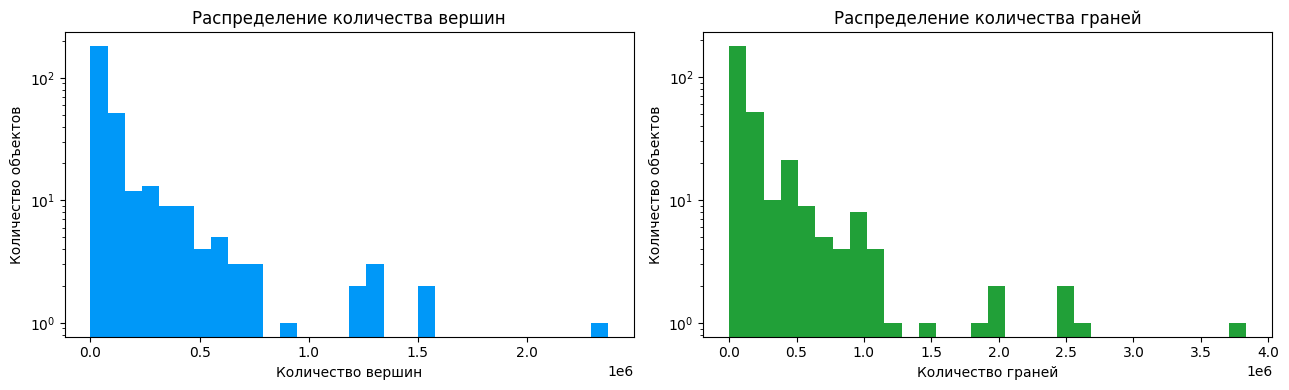

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(mesh_sample['vertices'], bins=30, color='#0098F8')
axes[0].set_title('Распределение количества вершин')
axes[0].set_xlabel('Количество вершин')
axes[0].set_ylabel('Количество объектов')
axes[0].set_yscale('log')

axes[1].hist(mesh_sample['faces'], bins=30, color='#21A038')
axes[1].set_title('Распределение количества граней')
axes[1].set_xlabel('Количество граней')
axes[1].set_ylabel('Количество объектов')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

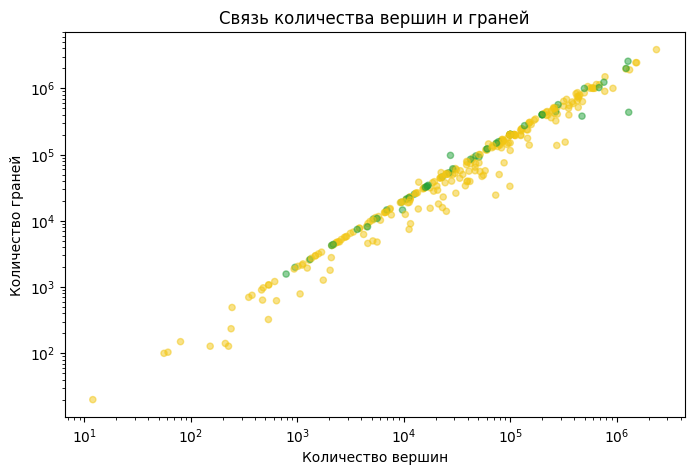

In [23]:
colors = mesh_sample['quality'].map({0: '#F2C614', 1: '#21A038'})

ax = mesh_sample.plot.scatter(
    x='vertices',
    y='faces',
    c=colors,
    figsize=(8, 5),
    alpha=0.5,
    loglog=True,
    title='Связь количества вершин и граней'
)

ax.set_xlabel('Количество вершин')
ax.set_ylabel('Количество граней');